In [ ]:
import os
import time
import torch
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Retrieve Hardware Specifications
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
mem_info = f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB" if torch.cuda.is_available() else "N/A"

# Create Directory for Reports and Spec Logs
SAVE_PATH = '/content/drive/MyDrive/May_Revision_Package_V2'
os.makedirs(SAVE_PATH, exist_ok=True)

with open(f"{SAVE_PATH}/hardware_specs_v2.txt", "w") as f:
    f.write(f"Hardware Used for Training:\n")
    f.write(f"GPU: {gpu_name}\n")
    f.write(f"VRAM: {mem_info}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")

print(f"🚀 Donanım:  {gpu_name} ({mem_info}). üzerinde eğitim için hazırız.")

Mounted at /content/drive
🚀 Donanım: NVIDIA L4 (23.66 GB) üzerinde eğitim için hazırız.


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import librosa
import zipfile
import shutil
from transformers import BertTokenizer, BertModel
from tqdm import tqdm

# Zip Extraction (For Faster Local Disk Access)
ZIP_PATH = '/content/drive/MyDrive/dataset.zip'
LOCAL_EXTRACT = '/content/dataset_working_v2'

if os.path.exists(LOCAL_EXTRACT): shutil.rmtree(LOCAL_EXTRACT)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_EXTRACT)

class SentBHC(nn.Module):
    def __init__(self):
        super(SentBHC, self).__init__()
        # Fusion Input Alignment: BERT (768) + MFCC (40) = 808
        self.fusion_layer = nn.Sequential(
            nn.Linear(808, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased to mitigate overfitting
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 3)
        )
    def forward(self, text_feat, audio_feat):
        x = torch.cat((text_feat, audio_feat), dim=1)
        return self.fusion_layer(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device).eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
class SentBHCDataset(Dataset):
    def __init__(self, csv_path, audio_dir):
        self.df = pd.read_csv(csv_path, sep=';', encoding='utf-8-sig')
        self.df.columns = self.df.columns.str.strip().str.lower()
        self.audio_dir = audio_dir
        self.label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, str(row['file_name']))
        y, sr = librosa.load(file_path, duration=3)
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
        inputs = tokenizer(str(row['transcription']), return_tensors="pt", truncation=True, padding='max_length', max_length=64).to(device)
        with torch.no_grad():
            bert_out = bert_model(**inputs).last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
        label = self.label_map.get(str(row['label']).strip().lower(), 1)
        return torch.FloatTensor(bert_out), torch.FloatTensor(mfcc), torch.tensor(label)

CSV_FILE = os.path.join(LOCAL_EXTRACT, 'dataset', 'metadata_v1_en.csv')
AUDIO_DIR = os.path.join(LOCAL_EXTRACT, 'dataset', 'audio_segments_v1_en')

# Calculate class weights to mitigate inherent dataset imbalance
df_temp = pd.read_csv(CSV_FILE, sep=';')
counts = df_temp['label'].value_counts()
# Applying inverse frequency weights assigns higher optimization priority to minority classes
weights = [1.0/counts['negative'], 1.0/counts['neutral'], 1.0/counts['positive']]
class_weights = torch.FloatTensor(weights).to(device)

dataset = SentBHCDataset(CSV_FILE, AUDIO_DIR)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
model = SentBHC().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights) # Weighted Cross-Entropy Loss for class imbalance
optimizer = optim.Adam(model.parameters(), lr=1e-4)

best_loss = float('inf')
patience = 5  # Halt training if there is no improvement for 5 consecutive epochs
trigger_times = 0

start_time = time.time()
print("🔥 Balanced Training (V2) Started...")

for epoch in range(30):
    model.train()
    running_loss = 0.0
    for texts, audios, labels in tqdm(train_loader):
        texts, audios, labels = texts.to(device), audios.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts, audios)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    current_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/30 - Loss: {current_loss:.4f}")

    # Early Stopping Logic
    if current_loss < best_loss:
        best_loss = current_loss
        torch.save(model.state_dict(), f"{SAVE_PATH}/model_v2_may.pth")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}")
            break

end_time = time.time()
total_duration = end_time - start_time

# Training Duration Logging
duration_str = f"Total Training Time: {total_duration/60:.2f} minutes"
print(f"✅ {duration_str}")

with open(f"{SAVE_PATH}/training_report_v2.txt", "w") as f:
    f.write(f"Training Status: Completed\n")
    f.write(f"{duration_str}\n")
    f.write(f"Final Loss: {best_loss:.4f}\n")

🔥 Balanced Training (V2) Started...


100%|██████████| 254/254 [03:45<00:00,  1.13it/s]


Epoch 1/30 - Loss: 1.0706


100%|██████████| 254/254 [03:24<00:00,  1.24it/s]


Epoch 2/30 - Loss: 1.0131


...

Epoch 28/30 - Loss: 0.4493


100%|██████████| 254/254 [03:30<00:00,  1.21it/s]


Epoch 29/30 - Loss: 0.4394


100%|██████████| 254/254 [03:29<00:00,  1.21it/s]

Epoch 30/30 - Loss: 0.4354
✅ Total Training Time: 103.30 minutes


100%|██████████| 254/254 [03:30<00:00,  1.21it/s]


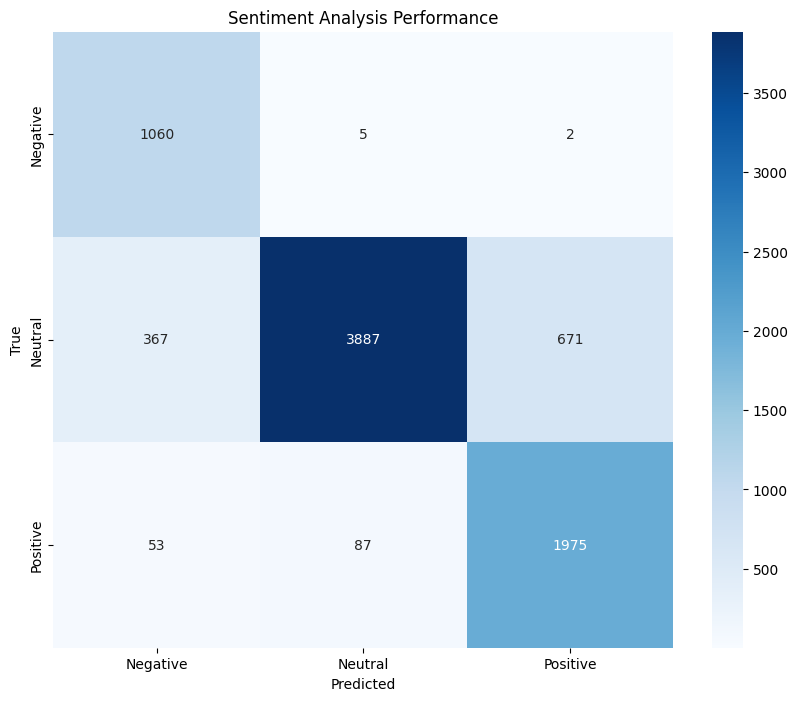

              precision    recall  f1-score   support

    Negative       0.72      0.99      0.83      1067
     Neutral       0.98      0.79      0.87      4925
    Positive       0.75      0.93      0.83      2115

    accuracy                           0.85      8107
   macro avg       0.81      0.91      0.84      8107
weighted avg       0.88      0.85      0.86      8107



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load(f"{SAVE_PATH}/model_v2_may.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for texts, audios, labels in tqdm(train_loader):
        texts, audios = texts.to(device), audios.to(device)
        outputs = model(texts, audios)
        all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix Görseli
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Analysis Performance')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(f"{SAVE_PATH}/confusion_matrix_may_v2.png", dpi=300)
plt.show()

# Classification Report
report = classification_report(all_labels, all_preds, target_names=['Negative', 'Neutral', 'Positive'])
with open(f"{SAVE_PATH}/metrics_v2.txt", "w") as f:
    f.write(report)
print(report)